# Sentiment Analysis - YouTube Comments

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import joblib

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('vader_lexicon', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.preprocessing import LabelEncoder

from langdetect import detect, DetectorFactory
from langdetect.lang_detect_exception import LangDetectException

import matplotlib.pyplot as plt

DetectorFactory.seed = 42
print('Libraries loaded.')

Libraries loaded.


## 2. Load Data

In [2]:
df = pd.read_csv('comments.csv')
print(f'Total rows loaded: {len(df)}')
print(f'Columns: {list(df.columns)}')
df.head()

Total rows loaded: 26169
Columns: ['video_id', 'comment_id', 'author_name', 'comment_text', 'like_count', 'published_at', 'reply_count']


,video_id,comment_id,author_name,comment_text,like_count,published_at,reply_count
0,Hz2F_S3Tl0Y,Ugy_VuwGw6WXcW3HSRZ4AaABAg,@redbull,check out the full story behind Felix's incred...,8161,2022-10-15T06:52:11Z,525
1,Hz2F_S3Tl0Y,Ugx4m7l4M95iRwV6fb54AaABAg,@madmat8771,2:26 flat what lol,0,2026-04-22T01:45:35Z,0
2,Hz2F_S3Tl0Y,UgyihhoqDyZZi5-4Xxt4AaABAg,@hessiride1729,Felix Baumgartner tribute,1,2026-04-22T01:23:58Z,0
3,Hz2F_S3Tl0Y,Ugy9atmSMkCHVynZv4B4AaABAg,@90sdiablo51,Red Bull gave him wiiings.,0,2026-04-22T00:00:28Z,0
4,Hz2F_S3Tl0Y,UgxhSkPz495KRWmDBj94AaABAg,@yourDEEPDARKthoughts,I'd imagine heights aren't a problem after this,0,2026-04-21T23:51:27Z,0


## 3. Filter English Comments

In [3]:
before_filter = len(df)

def detect_lang(text):
    try:
        if not isinstance(text, str) or len(text.strip()) < 3:
            return None
        return detect(text)
    except LangDetectException:
        return None

df['lang'] = df['comment_text'].apply(detect_lang)
df = df[df['lang'] == 'en'].copy()
df.drop(columns=['lang'], inplace=True)
df.reset_index(drop=True, inplace=True)

after_filter = len(df)
print(f'Before filter: {before_filter}')
print(f'After filter (English only): {after_filter}')
print(f'Removed: {before_filter - after_filter}')

Before filter: 26169
After filter (English only): 18602
Removed: 7567


## 4. Text Preprocessing

In [4]:
negation_words = {'not', 'no', 'nor', 'never', 'neither', 'nobody',
                  'nothing', 'nowhere', 'hardly', 'barely', 'scarcely'}
stop_words = set(stopwords.words('english')) - negation_words
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 1]
    return ' '.join(tokens)

df['clean_text'] = df['comment_text'].apply(preprocess)
df = df[df['clean_text'].str.strip().astype(bool)].copy()
df.reset_index(drop=True, inplace=True)
print(f'Rows after preprocessing: {len(df)}')
df[['comment_text', 'clean_text']].head(10)

Rows after preprocessing: 18521


,comment_text,clean_text
0,check out the full story behind Felix's incred...,check full story behind felixs incredible jump...
1,2:26 flat what lol,flat lol
2,Red Bull gave him wiiings.,red bull gave wiiings
3,I'd imagine heights aren't a problem after this,id imagine height arent problem
4,Man! Hats off to you bro. I don't know if I co...,man hat bro dont know could
5,"See, Earth is flat.",see earth flat
6,Fish eye lenses are cool I guess,fish eye lens cool guess
7,Anyone watching 21 April comment 🎉,anyone watching april comment
8,"RIP Mr Baumgartner, you were one hell of a bra...",rip mr baumgartner one hell brave guy
9,Don't show this video to flat earthers. Habibi😂,dont show video flat earthers habibi


## 5. Sentiment Labeling (VADER)

In [5]:
sia = SentimentIntensityAnalyzer()

def label_sentiment(text):
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['sentiment'] = df['comment_text'].apply(label_sentiment)
print('Sentiment distribution:')
print(df['sentiment'].value_counts())
print(f'\nTotal labeled: {len(df)}')

Sentiment distribution:
sentiment
neutral     8658
positive    5774
negative    4089
Name: count, dtype: int64

Total labeled: 18521


## 6. Feature Extraction (TF-IDF)

In [6]:
le = LabelEncoder()
y = le.fit_transform(df['sentiment'])
print(f'Label classes: {list(le.classes_)}')

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=5, max_df=0.8)
X = tfidf.fit_transform(df['clean_text'])
print(f'TF-IDF matrix shape: {X.shape}')

Label classes: ['negative', 'neutral', 'positive']
TF-IDF matrix shape: (18521, 4512)


## 7. Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train size: {X_train.shape[0]}')
print(f'Test size: {X_test.shape[0]}')

Train size: 14816
Test size: 3705


## 8. Model Training (LogisticRegression)

In [8]:
param_grid = {
    'C': [0.1, 0.5, 1, 3, 5, 10, 50],
    'penalty': ['l1', 'l2']
}

grid = GridSearchCV(
    LogisticRegression(
        solver='saga', max_iter=5000,
        class_weight={0: 1.7, 1: 0.65, 2: 1.35},
        random_state=42
    ),
    param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)

print(f'\nBest params: {grid.best_params_}')
print(f'Best CV f1_macro: {grid.best_score_:.4f}')

Fitting 3 folds for each of 14 candidates, totalling 42 fits

Best params: {'C': 1, 'penalty': 'l1'}
Best CV f1_macro: 0.8545


## 8.5 Post-Prediction Threshold Tuning

In [9]:
best_model = grid.best_estimator_
proba = best_model.predict_proba(X_test)

best_min_metric = 0
best_adj = np.array([1.0, 1.0, 1.0])

for neg_boost in np.arange(1.0, 1.3, 0.005):
    for neu_scale in np.arange(0.88, 1.01, 0.005):
        for pos_boost in np.arange(1.0, 1.15, 0.005):
            adj = np.array([neg_boost, neu_scale, pos_boost])
            adjusted = proba * adj
            preds = adjusted.argmax(axis=1)
            report = classification_report(y_test, preds, target_names=le.classes_, output_dict=True, zero_division=0)
            metrics = []
            for cls in le.classes_:
                for m in ['precision', 'recall', 'f1-score']:
                    metrics.append(report[cls][m])
            min_metric = min(metrics)
            if min_metric > best_min_metric:
                best_min_metric = min_metric
                best_adj = adj.copy()

print(f'Best adjustments: neg={best_adj[0]:.3f}, neu={best_adj[1]:.3f}, pos={best_adj[2]:.3f}')
print(f'Highest minimum metric: {best_min_metric:.4f}')

Best adjustments: neg=1.050, neu=0.880, pos=1.060
Highest minimum metric: 0.8460


Test Accuracy: 0.8955

Classification Report:
              precision    recall  f1-score   support

    negative       0.85      0.85      0.85       818
     neutral       0.92      0.94      0.93      1732
    positive       0.90      0.86      0.88      1155

    accuracy                           0.90      3705
   macro avg       0.89      0.88      0.88      3705
weighted avg       0.90      0.90      0.90      3705



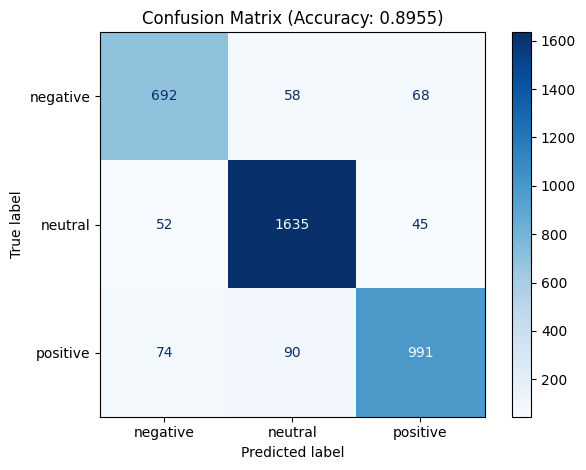

In [10]:
adjusted_proba = proba * best_adj
y_pred = adjusted_proba.argmax(axis=1)

acc = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {acc:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix (Accuracy: {acc:.4f})')
plt.tight_layout()
plt.show()

## 9. Save Model & Artifacts

In [11]:
joblib.dump(best_model, 'sentiment_model_lr.joblib')
joblib.dump(tfidf, 'tfidf_vectorizer.joblib')
joblib.dump(le, 'label_encoder.joblib')
joblib.dump(best_adj, 'threshold_adjustments.joblib')
print('Saved:')
print('  - sentiment_model_lr.joblib')
print('  - tfidf_vectorizer.joblib')
print('  - label_encoder.joblib')
print('  - threshold_adjustments.joblib')

Saved:
  - sentiment_model_lr.joblib
  - tfidf_vectorizer.joblib
  - label_encoder.joblib
  - threshold_adjustments.joblib


## 10. Inference Demo

In [12]:
model = joblib.load('sentiment_model_lr.joblib')
vectorizer = joblib.load('tfidf_vectorizer.joblib')
encoder = joblib.load('label_encoder.joblib')
adj = joblib.load('threshold_adjustments.joblib')

def predict(text):
    cleaned = preprocess(text)
    features = vectorizer.transform([cleaned])
    proba = model.predict_proba(features) * adj
    label_idx = proba.argmax(axis=1)[0]
    return encoder.inverse_transform([label_idx])[0]

test_comments = [
    'Thank you so much for sharing this knowledge, really helpful and inspiring!',
    'This is so boring, I could not even finish watching it.',
    'I watched this while eating lunch, pretty chill background video.'
]

print(f'{"Prediction":>12}  |  Comment')
print('-' * 80)
for comment in test_comments:
    result = predict(comment)
    print(f'{result:>12}  |  {comment}')

  Prediction  |  Comment
--------------------------------------------------------------------------------
    positive  |  Thank you so much for sharing this knowledge, really helpful and inspiring!
     neutral  |  This is so boring, I could not even finish watching it.
    positive  |  I watched this while eating lunch, pretty chill background video.
